## Build an n-qubit GHZ state in QpiAI Explorer Lab on Amazon Braket

In [1]:
#install amazon braket
%pip install amazon-braket-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 28.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 27.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 7.2 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=bb765120ae2eaa958d2a0

In [2]:
#import relevant functions
from braket.circuits import Circuit
from braket.devices import LocalSimulator

### Build an n-qubit GHZ state circuit

An n-qubit GHZ state is maximally entangled and which is an equal superposition of the states with all qubits at |0> or all qubits at |1>.

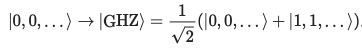

To create this state from a state with all qubits at |0>, we apply the Hadamard on the first qubit to take |0> to a superposition of |0> and |1>. Then we apply CNOT on every subsequent pair of qubits, which produces no change to the target qubit if the control qubit is |0> and flips the target qubit from |0> to |1>(or |1> to |0>) if the control qubit is |1>. The process is described in the figure below.

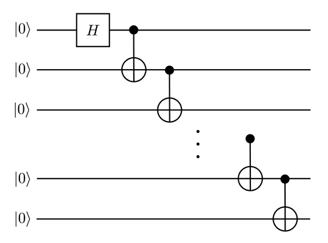

Hence, the superposition produces a maximally entangled final state with a superposition of all qubits at |0> and all qubits at |1>.

In [3]:
#circuit to create an n-qubit GHZ state

def create_ghz_state(n_qubit):
  circuit = Circuit()

  #apply hadamard on first qubit to create superposition of |0> and |1>
  circuit.h(0)

  #apply CNOT gate on all subsequent qubits to create maximally entangled GHZ state
  for qubit in range(0,n_qubit-1):
    circuit.cnot(control = qubit, target = qubit+1)

  return circuit

#test for n_qubits = 5 qubits

ghz_state = create_ghz_state(5)

print(ghz_state)

T  : │  0  │  1  │  2  │  3  │  4  │
      ┌───┐                         
q0 : ─┤ H ├───●─────────────────────
      └───┘   │                     
            ┌─┴─┐                   
q1 : ───────┤ X ├───●───────────────
            └───┘   │               
                  ┌─┴─┐             
q2 : ─────────────┤ X ├───●─────────
                  └───┘   │         
                        ┌─┴─┐       
q3 : ───────────────────┤ X ├───●───
                        └───┘   │   
                              ┌─┴─┐ 
q4 : ─────────────────────────┤ X ├─
                              └───┘ 
T  : │  0  │  1  │  2  │  3  │  4  │


### Test the circuit

In [4]:
# set up device
device = LocalSimulator()

# run circuit
result = device.run(ghz_state, shots=100).result()

# get measurement shots
counts = result.measurement_counts

# print counts
print(counts)

Counter({'00000': 54, '11111': 46})


### Plot Output

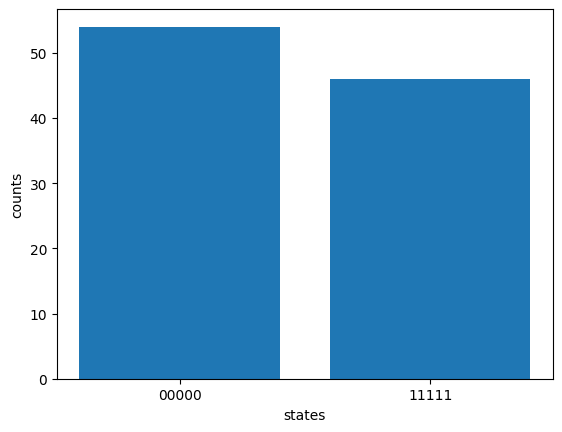

In [5]:
import matplotlib.pyplot as plt

# plot using Counter

plt.bar(counts.keys(), counts.values())
plt.xlabel('states')
plt.ylabel('counts')
plt.show()